In [119]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

# Now this works
import aqi_pkg as ap

In [154]:
from datetime import datetime, timedelta
from collections import deque, defaultdict, Counter

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("tableau-colorblind10")

from sqlalchemy.dialects.mysql import insert
from tqdm import tqdm

from aqi_pkg.db import get_session
from aqi_pkg.tables import Entry, MetricAverages, IsDuplicate, UnitConversions
from aqi_pkg.filters import *
from aqi_pkg.data_scripts.create_subindicies import *

import threading

In [121]:
filter = Filter(city=ap.tags.TRICITY_CITIES_LIST)

dataLoader = DataLoader(
    filters=filter
)

time = datetime.now()
print("Loading data...")
data_df = dataLoader.get_df()
print(f"Data loaded in {datetime.now() - time}")
print(data_df.shape)

Loading data...
Data loaded in 0:00:08.139130
(327502, 21)


---
# Check Anamolies in Data

In [122]:
print(data_df.columns)

['scrape_id', 'lat', 'lon', 'locationId', 'city', 'state', 'country', 'last_updated', 'AQI_IN', 'AQI_US', 'CO_PPB', 'NO2_PPB', 'O3_PPB', 'SO2_PPB', 'PM1_UGM3', 'PM2_5_UGM3', 'PM10_UGM3', 'H_PERCENT', 'T_C', 'TVOC_PPM', 'Noise_DB']


In [123]:
data_df.select(["lat", "lon"])\
    .unique()\
    .write_csv("unique_lat_lon.csv")

In [124]:
data_df.describe()

statistic,scrape_id,lat,lon,locationId,city,state,country,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB
str,f64,f64,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",327502.0,327502.0,327502.0,"""327502""","""327502""","""327502""","""327502""","""327502""",327502.0,327502.0,152833.0,152833.0,152833.0,152833.0,174669.0,327502.0,327502.0,313932.0,327502.0,174669.0,174669.0
"""null_count""",0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,174669.0,174669.0,174669.0,174669.0,152833.0,0.0,0.0,13570.0,0.0,152833.0,152833.0
"""mean""",9.8535e6,30.717603,76.792632,null,null,null,null,"""2026-01-13 03:53:12.005423""",252.355146,208.551438,526.62671,21.796804,20.462878,3.119595,73.09123,125.414013,164.595886,49.621316,16.080119,6.324712,52.292548
"""std""",5.7633e6,0.027121,0.052426,null,null,null,null,null,104.967766,70.85341,279.715516,16.699116,16.450871,3.143773,36.825858,62.517053,87.376524,17.173841,5.308489,12.515751,9.174774
"""min""",635.0,30.6323,76.6612,"""-160063""","""Chandigarh""","""Chandigarh""","""India""","""2025-11-09 17:22:00""",8.0,28.0,27.0,1.0,1.0,1.0,3.0,0.0,6.0,8.0,0.0,0.0,38.0
"""25%""",4.936857e6,30.6995,76.7577,null,null,null,null,"""2025-12-20 02:22:00""",163.0,168.0,324.0,9.0,8.0,2.0,46.0,79.0,99.0,37.0,12.0,0.19,45.0
"""50%""",9.603111e6,30.715,76.7883,null,null,null,null,"""2026-01-15 20:17:00""",280.0,191.0,470.0,15.0,19.0,2.0,66.0,114.0,147.0,47.0,15.0,0.55,49.0
"""75%""",1.4095537e7,30.7397,76.8283,null,null,null,null,"""2026-02-04 23:07:00""",330.0,234.0,745.0,32.0,28.0,3.0,93.0,159.0,211.0,64.0,19.7,4.36,59.0
"""max""",2.1125831e7,30.8085,77.0861,"""VIR4221""","""Zirakpur""","""Punjab""","""India""","""2026-03-06 21:32:00""",1299.0,1575.0,1000.0,200.0,188.0,100.0,360.0,865.0,1149.0,99.0,41.8,65.27,100.0


In [125]:
g = data_df.group_by("locationId")

out = g.agg(
    pl.len().alias("n_entries"),
    pl.col("last_updated").min().alias("first_updated"),
    pl.col("last_updated").max().alias("last_updated"),
)

out = out.sort("last_updated")
out

locationId,n_entries,first_updated,last_updated
str,u32,datetime[μs],datetime[μs]
"""B0A604509C7C""",996,2025-12-04 17:32:00,2025-12-13 15:08:00
"""B0A60451DDD4""",2608,2025-12-06 03:32:00,2025-12-25 21:32:00
"""48F6EE546F34""",2303,2025-12-16 17:02:00,2026-01-08 15:23:00
"""8856A6ED2614""",1442,2025-12-29 17:32:00,2026-01-15 13:47:00
"""48F6EE5481E0""",1691,2025-12-18 01:42:00,2026-03-06 10:02:00
"""B0A6044F16B8""",444,2026-01-29 07:06:00,2026-03-06 14:03:00
"""9C139E7D1574""",8735,2025-11-09 17:22:00,2026-03-06 20:14:00
"""8856A6FD31D8""",5046,2026-01-08 20:47:00,2026-03-06 21:16:00
"""ACA7048686CC""",847,2026-02-23 07:28:00,2026-03-06 21:25:00


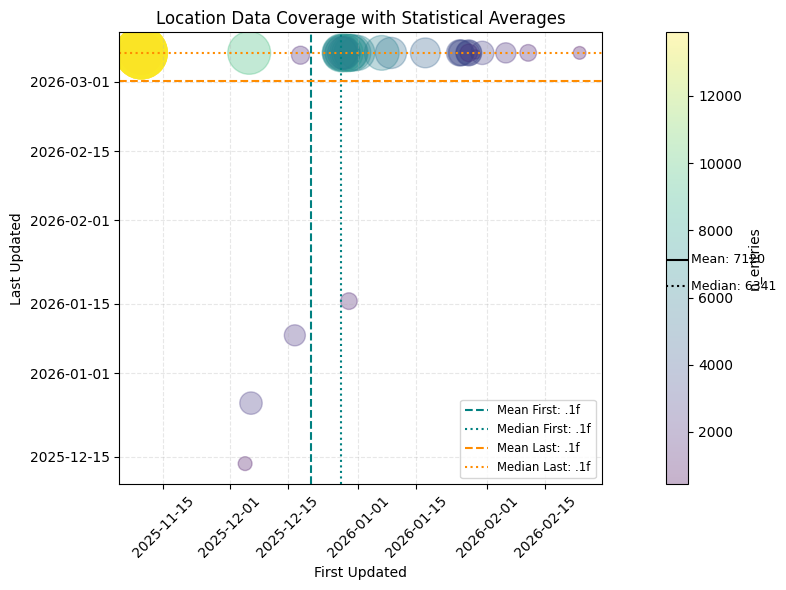

In [126]:
# Show Node Updates and Datapoints
pdf = out.to_pandas()
plt.figure(figsize=(8, 6))

# 2. Scatter plot
sc = plt.scatter(
    pdf["first_updated"],
    pdf["last_updated"],
    c=pdf["n_entries"],
    s=pdf["n_entries"] / 10,   # scale size
    alpha=0.3,
    cmap='viridis'             # Adding a colormap for better visibility
)

# 3. Calculate statistics (as you had them)
mean_last = pdf["last_updated"].mean()
median_last = pdf["last_updated"].median()
mean_first = pdf["first_updated"].mean()
median_first = pdf["first_updated"].median()
mean_n = pdf["n_entries"].mean()
median_n = pdf["n_entries"].median()

# 4. Plot vertical lines for 'first_updated'
plt.axvline(mean_first, color='teal', linestyle='--', linewidth=1.5, 
            label=f'Mean First: {mean_first:.1f}')
plt.axvline(median_first, color='teal', linestyle=':', linewidth=1.5, 
            label=f'Median First: {median_first:.1f}')

# 5. Plot horizontal lines for 'last_updated'
plt.axhline(mean_last, color='darkorange', linestyle='--', linewidth=1.5, 
            label=f'Mean Last: {mean_last:.1f}')
plt.axhline(median_last, color='darkorange', linestyle=':', linewidth=1.5, 
            label=f'Median Last: {median_last:.1f}')

# 6. Setup Colorbar and add mean/median tags
cb = plt.colorbar(sc, label="n_entries", pad=0.1)

# Tag mean/median on the colorbar axis itself
cb.ax.axhline(mean_n, color='black', linewidth=1.5)
cb.ax.text(1.1, mean_n, f'Mean: {mean_n:.0f}', va='center', 
           transform=cb.ax.get_yaxis_transform(), fontsize=9)

cb.ax.axhline(median_n, color='black', linestyle=':', linewidth=1.5)
cb.ax.text(1.1, median_n, f'Median: {median_n:.0f}', va='center', 
           transform=cb.ax.get_yaxis_transform(), fontsize=9)

# 7. Labels and Formatting
plt.xlabel("First Updated")
plt.ylabel("Last Updated")
plt.title("Location Data Coverage with Statistical Averages")
plt.legend(loc='lower right', fontsize='small')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

---
# Convert Units and Calculate Subindex

In [127]:
subindexToCalculate = {
    "NO2": 24,
    "O3": 8,
    "SO2": 24,
    "CO": 8,
    "PM2_5": 24,
    "PM10": 24,
}

df = data_df.clone()

from aqi_pkg.tags import UNIT_CONVERSION_MAP as units_conversion_map
df = convert_units(df, units_conversion_map)

units = ["PPB", "UGM3"]
for pollutant, hours in subindexToCalculate.items():
        for unit in units:
            pollutant_name = f"{pollutant}_{unit}"
            if pollutant == "CO": # Handle CO Units
                pollutant_name = pollutant_name.replace("_PPB", "_PPM").replace("_UGM3", "_MGM3")
            if "PM" in pollutant and "PP" in unit:
                continue # skips the rest of THIS iteration

            rolled = compute_rolling(df, pollutant_name, hours)
            df = attach_scrape_ids(df, rolled)

df.head()

scrape_id,lat,lon,locationId,city,state,country,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB,NO2_UGM3,O3_UGM3,SO2_UGM3,CO_MGM3,CO_PPM,NO2_PPB_24h_subindex,NO2_UGM3_24h_subindex,O3_PPB_8h_subindex,O3_UGM3_8h_subindex,SO2_PPB_24h_subindex,SO2_UGM3_24h_subindex,CO_PPM_8h_subindex,CO_MGM3_8h_subindex,PM2_5_UGM3_24h_subindex,PM10_UGM3_24h_subindex
i64,f64,f64,str,str,str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5472155,30.6324,76.7244,"""48F6EE546F34""","""Sahibzada Ajit Singh Nagar""","""Punjab""","""India""",2025-12-24 01:02:00,360,273,null,null,null,null,113.0,198.0,258.0,58.0,12.0,2.6,63.0,null,null,null,null,null,null,null,null,null,null,null,null,null,171.542857,226.721429
5359455,30.7289,76.7817,"""PLLODA000685""","""Chandigarh""","""Chandigarh""","""India""",2025-12-23 04:58:00,342,250,699.0,32.0,5.0,1.0,null,175.0,251.0,51.0,14.0,null,null,60.16,9.8,2.62,0.80385,0.699,40.204545,75.584545,22.159091,43.431818,4.015152,10.519697,0.879136,1.011007,156.606061,205.795455
9945794,30.7199,76.7386,"""13876""","""Chandigarh""","""Chandigarh""","""India""",2026-01-17 13:11:00,200,175,634.0,34.0,8.0,10.0,null,90.0,113.0,26.0,20.0,null,null,63.92,15.68,26.2,0.7291,0.634,41.752,78.49376,2.066667,4.050667,2.664,6.97968,0.659511,0.758438,184.592,247.24
9909568,30.7127,76.8283,"""E4B06332EC44""","""Chandigarh""","""Chandigarh""","""India""",2026-01-17 08:42:00,470,531,null,null,null,null,185.0,341.0,443.0,36.0,13.0,0.1,66.0,null,null,null,null,null,null,null,null,null,null,null,null,null,200.883333,254.225
7357053,30.6999,76.835,"""PLLODA000621""","""Panchkula""","""Chandigarh""","""India""",2026-01-04 09:53:00,303,199,322.0,11.0,21.0,4.0,null,124.0,170.0,59.0,12.0,null,null,20.68,41.16,10.48,0.3703,0.322,10.368794,19.493333,20.354167,39.894167,3.546099,9.29078,0.278583,0.320371,122.687943,173.617021


In [128]:
print(df.columns)

['scrape_id', 'lat', 'lon', 'locationId', 'city', 'state', 'country', 'last_updated', 'AQI_IN', 'AQI_US', 'CO_PPB', 'NO2_PPB', 'O3_PPB', 'SO2_PPB', 'PM1_UGM3', 'PM2_5_UGM3', 'PM10_UGM3', 'H_PERCENT', 'T_C', 'TVOC_PPM', 'Noise_DB', 'NO2_UGM3', 'O3_UGM3', 'SO2_UGM3', 'CO_MGM3', 'CO_PPM', 'NO2_PPB_24h_subindex', 'NO2_UGM3_24h_subindex', 'O3_PPB_8h_subindex', 'O3_UGM3_8h_subindex', 'SO2_PPB_24h_subindex', 'SO2_UGM3_24h_subindex', 'CO_PPM_8h_subindex', 'CO_MGM3_8h_subindex', 'PM2_5_UGM3_24h_subindex', 'PM10_UGM3_24h_subindex']


---
# Calculate AQI-India ourselves

In [129]:
from aqi_pkg.aqi_standards.in_cbcp import calculate_pollutant_aqi_cpcb
from aqi_pkg.aqi_standards.in_safar import calculate_pollutant_aqi_safar

def calculate_aqi(pollutant, value):
    # Helper function to have try catch here
    try:
        return calculate_pollutant_aqi_cpcb(pollutant, value)
    except Exception:
        print(f"CPCB WOMP: {Exception}")
        try:
            return calculate_pollutant_aqi_safar(pollutant, value)
        except Exception:
            print(f"SAFAR WOMP: {Exception}")
            return None

col_names = ['NO2_PPB_24h_subindex', 
             'NO2_UGM3_24h_subindex', 
             'O3_PPB_8h_subindex', 
             'O3_UGM3_8h_subindex', 
             'SO2_PPB_24h_subindex', 
             'SO2_UGM3_24h_subindex', 
             'CO_PPM_8h_subindex', 
             'CO_MGM3_8h_subindex', 
             'PM2_5_UGM3_24h_subindex', 
             'PM10_UGM3_24h_subindex'
             ]

exprs = []

for col in col_names:
    pollutant = "_".join(col.split("_")[:-2])  # removes '24h_subindex' or '8h_subindex'
    new_col_name = f"AQI_{pollutant}"
    expr = (
        pl.col(col)
        .map_elements(
            lambda x: calculate_aqi(pollutant, x)
            if x is not None else None,
            return_dtype=pl.Int64
        )
        .alias(new_col_name)
    )
    
    exprs.append(expr)

df = df.with_columns(exprs)
df.head()

scrape_id,lat,lon,locationId,city,state,country,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB,NO2_UGM3,O3_UGM3,SO2_UGM3,CO_MGM3,CO_PPM,NO2_PPB_24h_subindex,NO2_UGM3_24h_subindex,O3_PPB_8h_subindex,O3_UGM3_8h_subindex,SO2_PPB_24h_subindex,SO2_UGM3_24h_subindex,CO_PPM_8h_subindex,CO_MGM3_8h_subindex,PM2_5_UGM3_24h_subindex,PM10_UGM3_24h_subindex,AQI_NO2_PPB,AQI_NO2_UGM3,AQI_O3_PPB,AQI_O3_UGM3,AQI_SO2_PPB,AQI_SO2_UGM3,AQI_CO_PPM,AQI_CO_MGM3,AQI_PM2_5_UGM3,AQI_PM10_UGM3
i64,f64,f64,str,str,str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
5472155,30.6324,76.7244,"""48F6EE546F34""","""Sahibzada Ajit Singh Nagar""","""Punjab""","""India""",2025-12-24 01:02:00,360,273,null,null,null,null,113.0,198.0,258.0,58.0,12.0,2.6,63.0,null,null,null,null,null,null,null,null,null,null,null,null,null,171.542857,226.721429,null,null,null,null,null,null,null,null,148,185
5359455,30.7289,76.7817,"""PLLODA000685""","""Chandigarh""","""Chandigarh""","""India""",2025-12-23 04:58:00,342,250,699.0,32.0,5.0,1.0,null,175.0,251.0,51.0,14.0,null,null,60.16,9.8,2.62,0.80385,0.699,40.204545,75.584545,22.159091,43.431818,4.015152,10.519697,0.879136,1.011007,156.606061,205.795455,40,76,22,43,4,11,1,1,138,171
9945794,30.7199,76.7386,"""13876""","""Chandigarh""","""Chandigarh""","""India""",2026-01-17 13:11:00,200,175,634.0,34.0,8.0,10.0,null,90.0,113.0,26.0,20.0,null,null,63.92,15.68,26.2,0.7291,0.634,41.752,78.49376,2.066667,4.050667,2.664,6.97968,0.659511,0.758438,184.592,247.24,42,78,2,4,3,7,1,1,157,198
9909568,30.7127,76.8283,"""E4B06332EC44""","""Chandigarh""","""Chandigarh""","""India""",2026-01-17 08:42:00,470,531,null,null,null,null,185.0,341.0,443.0,36.0,13.0,0.1,66.0,null,null,null,null,null,null,null,null,null,null,null,null,null,200.883333,254.225,null,null,null,null,null,null,null,null,167,204
7357053,30.6999,76.835,"""PLLODA000621""","""Panchkula""","""Chandigarh""","""India""",2026-01-04 09:53:00,303,199,322.0,11.0,21.0,4.0,null,124.0,170.0,59.0,12.0,null,null,20.68,41.16,10.48,0.3703,0.322,10.368794,19.493333,20.354167,39.894167,3.546099,9.29078,0.278583,0.320371,122.687943,173.617021,10,19,20,40,4,9,0,0,115,149


In [198]:
# Aggregate AQI_CPCB, AQI_SAFAR
aqi_cols = [c for c in df.columns if "AQI_" in c and "IN" not in c and "US" not in c]
aqi_cols.sort()
print(aqi_cols)

cpcb_cols = [
    c for c in aqi_cols
    if any(k in c for k in ["NO2_UGM3", "O3_UGM3", "SO2_UGM3", "CO_MGM3", "PM2_5", "PM10"])
]

safar_cols = [
    c for c in aqi_cols
    if any(k in c for k in ["CO_PPM", "NO2_PPB", "O3_PPB", "PM2_5", "PM10"])
]

df = df.with_columns([
    pl.max_horizontal([pl.col(c) for c in cpcb_cols]).alias("AQI_CPCB"),
    pl.max_horizontal([pl.col(c) for c in safar_cols]).alias("AQI_SAFAR"),
])

rho = 2.2

df = df.with_columns(
    (
        sum(pl.col(col).pow(rho) for col in cpcb_cols)
        .pow(1 / rho)
    ).alias("AQI_rho")
)

df.head()

['AQI_CO_MGM3', 'AQI_CO_PPM', 'AQI_CPCB', 'AQI_NO2_PPB', 'AQI_NO2_UGM3', 'AQI_O3_PPB', 'AQI_O3_UGM3', 'AQI_PM10_UGM3', 'AQI_PM2_5_UGM3', 'AQI_SAFAR', 'AQI_SO2_PPB', 'AQI_SO2_UGM3', 'AQI_rho']


scrape_id,lat,lon,locationId,city,state,country,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB,NO2_UGM3,O3_UGM3,SO2_UGM3,CO_MGM3,CO_PPM,NO2_PPB_24h_subindex,NO2_UGM3_24h_subindex,O3_PPB_8h_subindex,O3_UGM3_8h_subindex,SO2_PPB_24h_subindex,SO2_UGM3_24h_subindex,CO_PPM_8h_subindex,CO_MGM3_8h_subindex,PM2_5_UGM3_24h_subindex,PM10_UGM3_24h_subindex,AQI_NO2_PPB,AQI_NO2_UGM3,AQI_O3_PPB,AQI_O3_UGM3,AQI_SO2_PPB,AQI_SO2_UGM3,AQI_CO_PPM,AQI_CO_MGM3,AQI_PM2_5_UGM3,AQI_PM10_UGM3,AQI_CPCB,AQI_SAFAR,AQI_rho
i64,f64,f64,str,str,str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64
5472155,30.6324,76.7244,"""48F6EE546F34""","""Sahibzada Ajit Singh Nagar""","""Punjab""","""India""",2025-12-24 01:02:00,360,273,null,null,null,null,113.0,198.0,258.0,58.0,12.0,2.6,63.0,null,null,null,null,null,null,null,null,null,null,null,null,null,171.542857,226.721429,null,null,null,null,null,null,null,null,148,185,185,185,null
5359455,30.7289,76.7817,"""PLLODA000685""","""Chandigarh""","""Chandigarh""","""India""",2025-12-23 04:58:00,342,250,699.0,32.0,5.0,1.0,null,175.0,251.0,51.0,14.0,null,null,60.16,9.8,2.62,0.80385,0.699,40.204545,75.584545,22.159091,43.431818,4.015152,10.519697,0.879136,1.011007,156.606061,205.795455,40,76,22,43,4,11,1,1,138,171,171,171,225.741804
9945794,30.7199,76.7386,"""13876""","""Chandigarh""","""Chandigarh""","""India""",2026-01-17 13:11:00,200,175,634.0,34.0,8.0,10.0,null,90.0,113.0,26.0,20.0,null,null,63.92,15.68,26.2,0.7291,0.634,41.752,78.49376,2.066667,4.050667,2.664,6.97968,0.659511,0.758438,184.592,247.24,42,78,2,4,3,7,1,1,157,198,198,198,254.011513
9909568,30.7127,76.8283,"""E4B06332EC44""","""Chandigarh""","""Chandigarh""","""India""",2026-01-17 08:42:00,470,531,null,null,null,null,185.0,341.0,443.0,36.0,13.0,0.1,66.0,null,null,null,null,null,null,null,null,null,null,null,null,null,200.883333,254.225,null,null,null,null,null,null,null,null,167,204,204,204,null
7357053,30.6999,76.835,"""PLLODA000621""","""Panchkula""","""Chandigarh""","""India""",2026-01-04 09:53:00,303,199,322.0,11.0,21.0,4.0,null,124.0,170.0,59.0,12.0,null,null,20.68,41.16,10.48,0.3703,0.322,10.368794,19.493333,20.354167,39.894167,3.546099,9.29078,0.278583,0.320371,122.687943,173.617021,10,19,20,40,4,9,0,0,115,149,149,149,186.253251


## Look at results of one location

In [199]:
from aqi_pkg.tags import CPCB_NODES_COORDS

interest_location = "Sector 22"
interest_coords = CPCB_NODES_COORDS[interest_location]
interest_locationid = df.filter(
    (pl.col("lat") == interest_coords[0]) &
    (pl.col("lon") == interest_coords[1])
).select("locationId").unique().item()
interest_locationid

'13741'

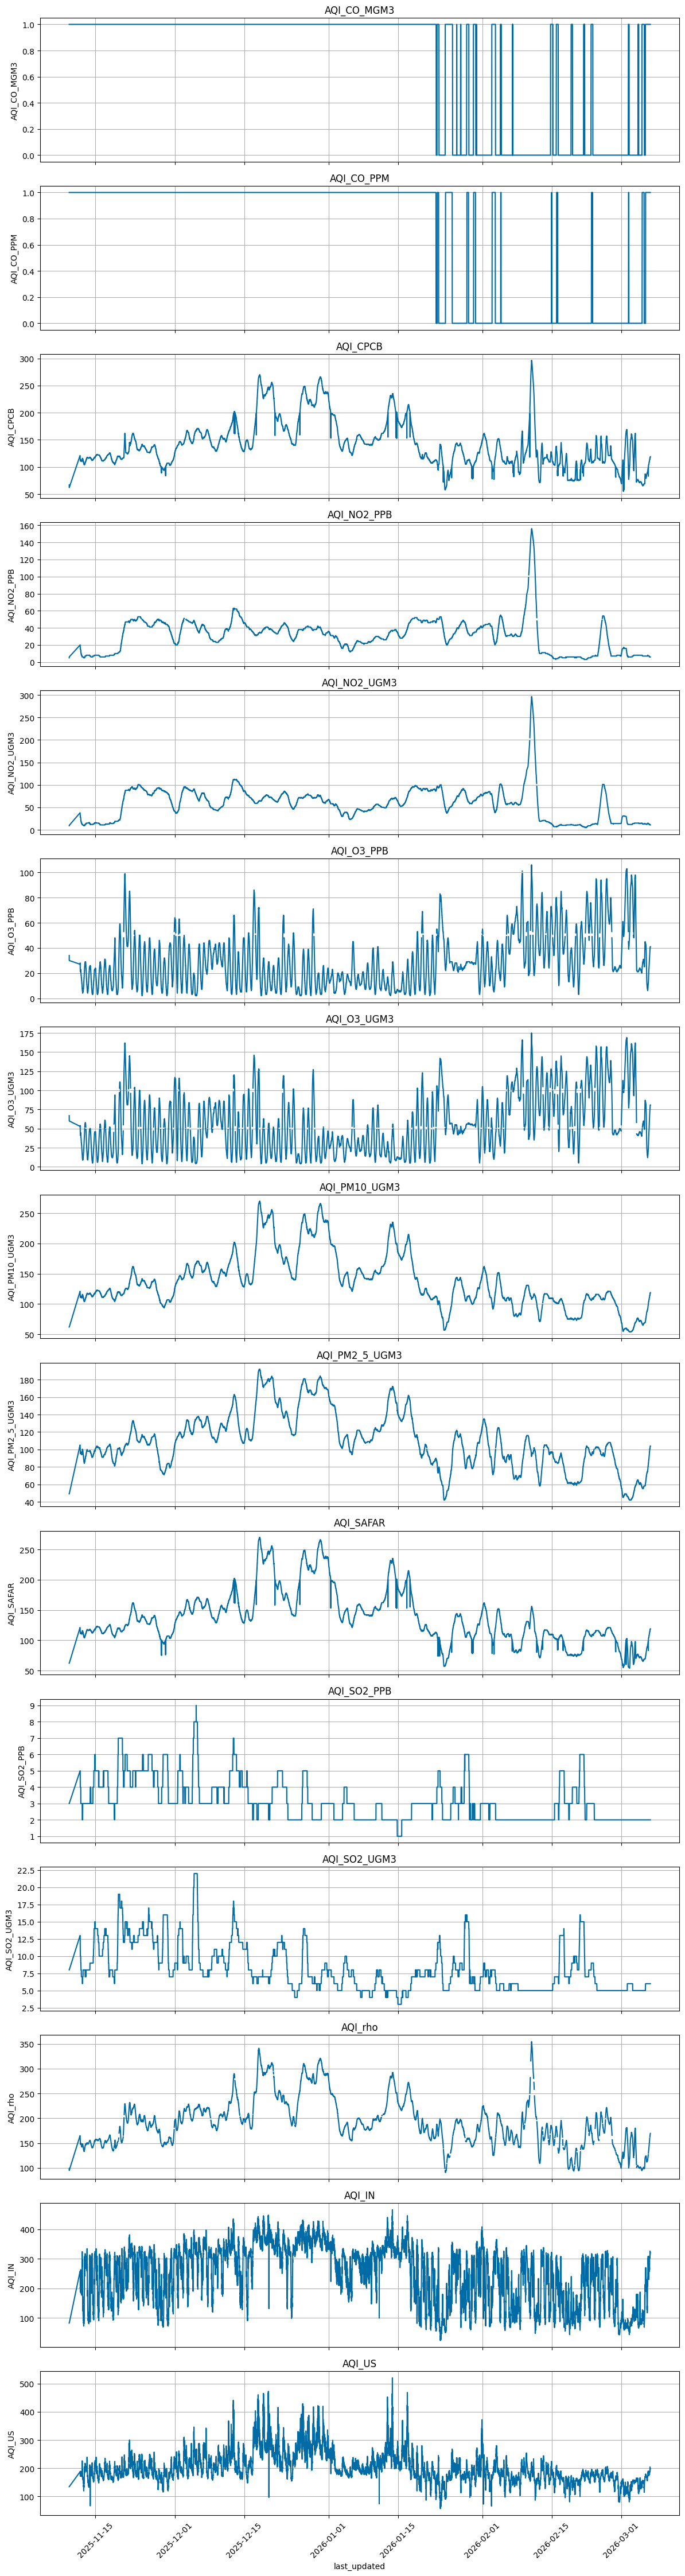

In [200]:
aqi_cols.extend(["AQI_IN", "AQI_US", "AQI_CPCB", "AQI_SAFAR", "AQI_rho"])
aqi_cols = list(dict.fromkeys(aqi_cols))

filtered = (
    df
    .filter(
        (pl.col("locationId") == interest_locationid) &
        (pl.col("last_updated") >= pl.datetime(2025, 2, 1)) &
        (pl.col("last_updated") <= pl.datetime(2026, 3, 10))
    )
    .select(["last_updated"] + aqi_cols)
    .sort("last_updated")
)

pdf = filtered.to_pandas()

n = len(aqi_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, col in zip(axes, aqi_cols):
    ax.plot(pdf["last_updated"], pdf[col])
    ax.set_ylabel(col)
    ax.set_title(col)
    ax.grid("on")

axes[-1].set_xlabel("last_updated")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

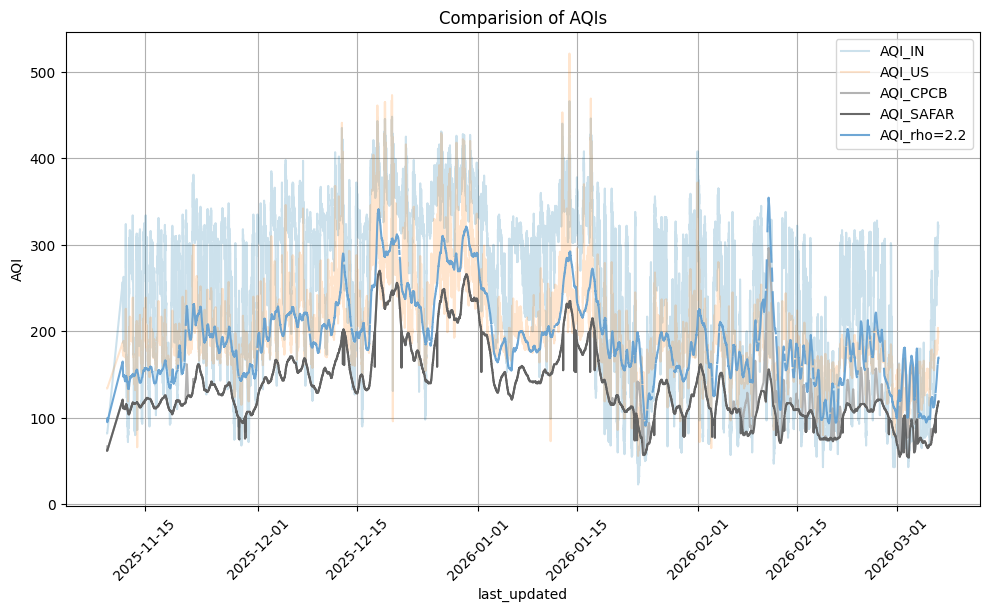

In [201]:
plt.figure(figsize=(10, 6))

plt.plot(pdf["last_updated"], pdf["AQI_IN"], label="AQI_IN", alpha = 0.2)
plt.plot(pdf["last_updated"], pdf["AQI_US"], label="AQI_US", alpha = 0.2)
plt.plot(pdf["last_updated"], pdf["AQI_CPCB"], label="AQI_CPCB", alpha=0.9)
plt.plot(pdf["last_updated"], pdf["AQI_SAFAR"], label="AQI_SAFAR", alpha=0.9)
plt.plot(pdf["last_updated"], pdf["AQI_rho"], label=f"AQI_rho={rho}", alpha=0.9)


plt.xlabel("last_updated")
plt.ylabel("AQI")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(visible=True)
plt.title("Comparision of AQIs")
plt.show()

---
# Debugging Stuff

## Something wrong with the CO values - subindex and data
> Side tangent, is fixed now

findings:
- In this dataset, only 9 entries where CO_PPB is >= 1000
- The unit conversion is also fine, but i think the AQI subindex thing is where it's messing up for CO

fix:
- CO values all being under 1000 ppb when the first breakpoint is defined at 1000 ppb implies that CO conc's are very good amd subindex will be very low.
    - Used the breakpoints defined for MGM3 after converted CO_PPB -> CO_MGM3 instead of using breakpoints of (MGM3 * 1000) i.e. supposed breakpoints for UGM3.
- I don't know how accuracte and good this fix is tho, so check CPCB reported numbers for CO to make sure.

In [202]:
exp_df = df.filter(
        (pl.col("locationId") == interest_locationid) &
        (pl.col("last_updated") >= pl.datetime(2026, 2, 1)) &
        (pl.col("last_updated") <= pl.datetime(2026, 2, 10))
    ).drop(["scrape_id", "lat", "lon", "city", "state", "country"])

exp_df.filter(pl.col("CO_PPB") >= 1000 ).describe()

statistic,locationId,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB,NO2_UGM3,O3_UGM3,SO2_UGM3,CO_MGM3,CO_PPM,NO2_PPB_24h_subindex,NO2_UGM3_24h_subindex,O3_PPB_8h_subindex,O3_UGM3_8h_subindex,SO2_PPB_24h_subindex,SO2_UGM3_24h_subindex,CO_PPM_8h_subindex,CO_MGM3_8h_subindex,PM2_5_UGM3_24h_subindex,PM10_UGM3_24h_subindex,AQI_NO2_PPB,AQI_NO2_UGM3,AQI_O3_PPB,AQI_O3_UGM3,AQI_SO2_PPB,AQI_SO2_UGM3,AQI_CO_PPM,AQI_CO_MGM3,AQI_PM2_5_UGM3,AQI_PM10_UGM3,AQI_CPCB,AQI_SAFAR,AQI_rho
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""3""","""3""",3.0,3.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,3.0,3.0,0.0,0.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2026-02-04 11:20:40""",224.333333,180.333333,1000.0,48.333333,8.333333,3.0,null,97.333333,121.333333,49.666667,18.666667,null,null,90.866667,16.333333,7.86,1.15,1.0,50.141204,94.265463,19.451531,38.125,2.034722,5.330972,0.164035,0.18864,131.895833,169.5,50.0,94.0,19.333333,38.0,2.0,5.0,0.0,0.0,121.333333,146.666667,146.666667,146.666667,204.908059
"""std""",null,null,22.030282,4.50925,0.0,1.154701,0.57735,0.0,null,6.506407,5.131601,1.154701,0.57735,null,null,2.170837,1.131607,0.0,0.0,0.0,0.934727,1.757286,1.077808,2.112504,0.027778,0.072778,0.07273,0.083639,1.275436,2.215278,1.414214,2.0,1.527525,2.0,0.0,0.0,0.0,0.0,0.57735,1.527525,1.527525,1.527525,0.750121
"""min""","""13741""","""2026-02-04 10:41:00""",203.0,176.0,1000.0,47.0,8.0,3.0,null,91.0,117.0,49.0,18.0,null,null,88.36,15.68,7.86,1.15,1.0,49.159722,92.420278,18.375,36.015,2.006944,5.258194,0.091714,0.105471,130.6875,167.284722,49.0,92.0,18.0,36.0,2.0,5.0,0.0,0.0,121.0,145.0,145.0,145.0,204.143384
"""25%""",null,"""2026-02-04 11:22:00""",223.0,180.0,1000.0,49.0,8.0,3.0,null,97.0,120.0,49.0,19.0,null,null,92.12,15.68,7.86,1.15,1.0,50.243056,94.456944,19.44898,38.12,2.034722,5.330972,0.163224,0.187708,131.770833,169.5,49.0,94.0,19.0,38.0,2.0,5.0,0.0,0.0,121.0,147.0,147.0,147.0,204.938065
"""50%""",null,"""2026-02-04 11:22:00""",223.0,180.0,1000.0,49.0,8.0,3.0,null,97.0,120.0,49.0,19.0,null,null,92.12,15.68,7.86,1.15,1.0,50.243056,94.456944,19.44898,38.12,2.034722,5.330972,0.163224,0.187708,131.770833,169.5,51.0,94.0,19.0,38.0,2.0,5.0,0.0,0.0,121.0,147.0,147.0,147.0,204.938065
"""75%""",null,"""2026-02-04 11:59:00""",247.0,185.0,1000.0,49.0,9.0,3.0,null,104.0,127.0,51.0,19.0,null,null,92.12,17.64,7.86,1.15,1.0,51.020833,95.919167,20.530612,40.24,2.0625,5.40375,0.237167,0.272742,133.229167,171.715278,51.0,96.0,21.0,40.0,2.0,5.0,0.0,0.0,122.0,148.0,148.0,148.0,205.642726
"""max""","""13741""","""2026-02-04 11:59:00""",247.0,185.0,1000.0,49.0,9.0,3.0,null,104.0,127.0,51.0,19.0,null,null,92.12,17.64,7.86,1.15,1.0,51.020833,95.919167,20.530612,40.24,2.0625,5.40375,0.237167,0.272742,133.229167,171.715278,51.0,96.0,21.0,40.0,2.0,5.0,0.0,0.0,122.0,148.0,148.0,148.0,205.642726


In [203]:
from aqi_pkg.aqi_standards.in_cbcp import BREAKPOINTS as CPCB_BREAKPOINTS
from aqi_pkg.aqi_standards.in_safar import BREAKPOINTS as SAFAR_BREAKPOINTS
print(CPCB_BREAKPOINTS["CO_MGM3"])
print(SAFAR_BREAKPOINTS["CO_PPM"])
exp_df.select(["last_updated", "CO_PPB", "CO_PPM", "CO_PPM_8h_subindex", "CO_MGM3", "CO_MGM3_8h_subindex", "AQI_CO_MGM3"]).head(10)

[(0, 1.0), (1.1, 2.0), (2.1, 8.7), (10, 14.8), (17, 29.7), (34, inf)]
[(0, 0.9), (1.0, 1.7), (1.8, 8.7), (8.8, 14.8), (14.9, 29.7), (29.8, 40)]


last_updated,CO_PPB,CO_PPM,CO_PPM_8h_subindex,CO_MGM3,CO_MGM3_8h_subindex,AQI_CO_MGM3
datetime[μs],f64,f64,f64,f64,f64,i64
2026-02-05 01:29:00,368.0,0.368,0.388,0.4232,0.4462,0
2026-02-07 19:52:00,485.0,0.485,0.1864,0.55775,0.21436,0
2026-02-05 15:52:00,404.0,0.404,0.416714,0.4646,0.479221,0
2026-02-05 23:10:00,59.0,0.059,0.363735,0.06785,0.418295,0
2026-02-05 01:11:00,364.0,0.364,0.387755,0.4186,0.445918,0
2026-02-02 14:59:00,348.0,0.348,0.375347,0.4002,0.431649,0
2026-02-07 05:52:00,426.0,0.426,0.40116,0.4899,0.461334,0
2026-02-02 23:11:00,792.0,0.792,0.487021,0.9108,0.560074,1
2026-02-03 17:28:00,69.0,0.069,0.335271,0.07935,0.385561,0


## Check if rolling average computed correctly

In [204]:
exp_df.select(["last_updated", 
               'PM2_5_UGM3',
               'PM2_5_UGM3_24h_subindex',
               'PM10_UGM3',
               'PM10_UGM3_24h_subindex']
               ).write_csv(f"PM Data at {interest_location}.csv")

---
# Correlation of pollutants and AQI Metrics

In [205]:
# Previously defined lists
print(df.columns)
print(aqi_cols)
print(cpcb_cols)
print(safar_cols)

['scrape_id', 'lat', 'lon', 'locationId', 'city', 'state', 'country', 'last_updated', 'AQI_IN', 'AQI_US', 'CO_PPB', 'NO2_PPB', 'O3_PPB', 'SO2_PPB', 'PM1_UGM3', 'PM2_5_UGM3', 'PM10_UGM3', 'H_PERCENT', 'T_C', 'TVOC_PPM', 'Noise_DB', 'NO2_UGM3', 'O3_UGM3', 'SO2_UGM3', 'CO_MGM3', 'CO_PPM', 'NO2_PPB_24h_subindex', 'NO2_UGM3_24h_subindex', 'O3_PPB_8h_subindex', 'O3_UGM3_8h_subindex', 'SO2_PPB_24h_subindex', 'SO2_UGM3_24h_subindex', 'CO_PPM_8h_subindex', 'CO_MGM3_8h_subindex', 'PM2_5_UGM3_24h_subindex', 'PM10_UGM3_24h_subindex', 'AQI_NO2_PPB', 'AQI_NO2_UGM3', 'AQI_O3_PPB', 'AQI_O3_UGM3', 'AQI_SO2_PPB', 'AQI_SO2_UGM3', 'AQI_CO_PPM', 'AQI_CO_MGM3', 'AQI_PM2_5_UGM3', 'AQI_PM10_UGM3', 'AQI_CPCB', 'AQI_SAFAR', 'AQI_rho']
['AQI_CO_MGM3', 'AQI_CO_PPM', 'AQI_CPCB', 'AQI_NO2_PPB', 'AQI_NO2_UGM3', 'AQI_O3_PPB', 'AQI_O3_UGM3', 'AQI_PM10_UGM3', 'AQI_PM2_5_UGM3', 'AQI_SAFAR', 'AQI_SO2_PPB', 'AQI_SO2_UGM3', 'AQI_rho', 'AQI_IN', 'AQI_US']
['AQI_CO_MGM3', 'AQI_NO2_UGM3', 'AQI_O3_UGM3', 'AQI_PM10_UGM3', 'AQI_

In [206]:
interested_df = df.filter(pl.col("locationId") == interest_locationid)

In [207]:
aqi_metrics = ["AQI_IN", "AQI_US", "AQI_SAFAR", "AQI_CPCB", "AQI_rho"]

results = []
for metric in aqi_metrics:
    pollutants = list(set(cpcb_cols + safar_cols))

    for p in pollutants:
        corr = interested_df.select(pl.corr(metric, p)).item()

        results.append({
            "AQI_metric": metric,
            "pollutant": p,
            "correlation": corr
        })

corr_df = pl.DataFrame(results)

# Pivot to matrix form 
corr_matrix = corr_df.pivot(
    values="correlation",
    index="pollutant",
    on="AQI_metric"
)

corr_matrix

pollutant,AQI_IN,AQI_US,AQI_SAFAR,AQI_CPCB,AQI_rho
str,f64,f64,f64,f64,f64
"""AQI_PM2_5_UGM3""",0.7274,0.760263,0.981347,0.921366,0.931215
"""AQI_NO2_PPB""",0.168324,0.183614,0.296674,0.370493,0.482876
"""AQI_O3_PPB""",-0.095239,-0.083421,-0.336605,-0.196239,-0.095194
"""AQI_SO2_UGM3""",0.029154,-0.010725,-0.013372,-0.055925,0.010712
"""AQI_CO_MGM3""",0.416883,0.378968,0.443988,0.340662,0.327158
"""AQI_O3_UGM3""",-0.094434,-0.081565,-0.348151,-0.216925,-0.108908
"""AQI_NO2_UGM3""",0.185488,0.19717,0.302904,0.37038,0.48492
"""AQI_CO_PPM""",0.434692,0.397102,0.469612,0.369345,0.354584
"""AQI_PM10_UGM3""",0.703812,0.760732,0.996688,0.938303,0.932765


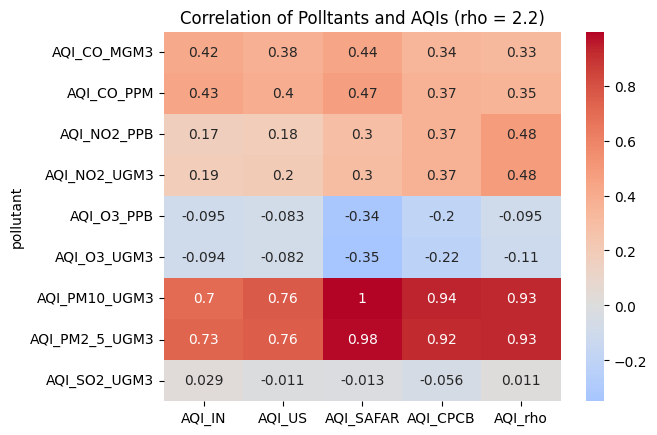

In [208]:
sns.heatmap(
    corr_matrix.to_pandas().set_index("pollutant").sort_index(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title(f"Correlation of Polltants and AQIs (rho = {rho})")
plt.show()